In [ ]:
!pip install keras-tcn

In [1]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LayerNormalization, TimeDistributed, Dense, RepeatVector
from tensorflow.keras.utils import plot_model
from tcn import TCN

ModuleNotFoundError: No module named 'tcn'

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input, GRU, TimeDistributed, Dense # Import GRU
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [ ]:
# data = df.drop(columns=['date']).values

In [ ]:
# data = data.astype(np.float32)

In [ ]:
# t = 48
# n = len(data)    # time step
# m = np.arange(0, n-2*t+1)
# xi_enc = np.array([data[i:(i+t), :] for i in m])
# xi_dec = np.array([data[(i+t-1):(i+2*t-1), :] for i in m])
# xp_dec = np.array([data[(i+t):(i+2*t), :] for i in m])

In [ ]:
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense, TimeDistributed
# from tensorflow.keras import optimizers
# from tcn import TCN  # Import TCN layer
# import matplotlib.pyplot as plt
# import numpy as np
# import pickle


# n_hidden = 100
# n_step = 24 * 2
# n_feat = 6

# # Encoder
# i_enc = Input(batch_shape=(None, n_step, n_feat))
# h_enc = TCN(
#     nb_filters=n_hidden,
#     kernel_size=3,
#     nb_stacks=1,
#     dilations=[1, 2, 4],
#     padding='causal',
#     use_skip_connections=True,
#     return_sequences=False,
#     activation='relu'
# )(i_enc)

# # Decoder
# i_dec = Input(batch_shape=(None, n_step, n_feat))
# o_dec = TCN(
#     nb_filters=n_hidden,
#     kernel_size=3,
#     nb_stacks=1,
#     dilations=[1, 2, 4],
#     padding='causal',
#     use_skip_connections=True,
#     return_sequences=True,
#     activation='relu'
# )(i_dec)
# y_dec = TimeDistributed(Dense(n_feat))(o_dec)

# model = Model([i_enc, i_dec], y_dec)
# model.compile(loss='mse',
#               optimizer=optimizers.Adam(learning_rate=0.001))
# model.name = 'Seq2SeqencodingwithTCN'
# model.summary()

Model: "Seq2SeqencodingwithTCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 48, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_5 (TCN)         │ (None, 48, 100)   │    153,100 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 48, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 48, 6)     │        606 │ tcn_5[0][0]       │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 153,706 (600.41 KB)

 Trainable params: 153,706 (600.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# hist = model.fit([xi_enc, xi_dec], xp_dec,
#                  batch_size=200, epochs=100)
# model.save_weights("models/seq2seq.h5")

# plt.plot(hist.history['loss'], color='red')
# plt.title("Loss history")
# plt.xlabel("epoch")
# plt.ylabel("loss")
# plt.show()

Epoch 1/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 209s 196ms/step - loss: 55019.0156
Epoch 2/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 260s 194ms/step - loss: 40.4945
Epoch 3/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 257s 189ms/step - loss: 88.3188
Epoch 4/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 200s 187ms/step - loss: 84.0970
Epoch 5/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 202s 188ms/step - loss: 77.0093
Epoch 6/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 202s 188ms/step - loss: 79.5840
Epoch 7/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 202s 188ms/step - loss: 39.4757
Epoch 8/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 203s 190ms/step - loss: 77.1921
Epoch 9/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 200s 188ms/step - loss: 18.8973
Epoch 10/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 198s 188ms/step - loss: 23.4488
Epoch 11/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 203s 189ms/step - loss: 38.8071
Epoch 12/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 203s 190ms/step - loss: 43.5615
Epoch 13/100
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 202s 189ms/step - loss: 9.3772
Epoch 14/100
1052/1

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense, TimeDistributed
# from tcn import TCN

# # Parameters
# n_step = 48       # input sequence length
# n_feat = 6        # number of features per time step
# n_hidden = 128    # hidden size / number of filters in TCN
# n_future = 48     # number of future steps to predict


# i_enc = Input(shape=(n_step, n_feat))

# h_enc_seq = TCN(
#     nb_filters=n_hidden,
#     kernel_size=3,
#     nb_stacks=1,
#     dilations=[1, 2, 4],
#     padding='causal',
#     use_skip_connections=True,
#     return_sequences=True,
#     activation='relu'
# )(i_enc)

# # Take last hidden state as encoded context vector
# from tensorflow.keras.layers import Lambda
# h_enc = Lambda(lambda x: x[:, -1, :])(h_enc_seq)

# Encoder = Model(i_enc, h_enc)


# # Define single-step decoder TCN
# SingleStepTCN = TCN(
#     nb_filters=n_hidden,
#     kernel_size=3,
#     nb_stacks=1,
#     dilations=[1, 2, 4],
#     padding='causal',
#     use_skip_connections=True,
#     return_sequences=True,
#     activation='relu'
# )

# # Output layer
# ManyOUT = TimeDistributed(Dense(n_feat))

# # Input for decoder
# i_dec = Input(shape=(1, n_feat))  # shape: (batch_size, 1, n_feat)

# # Initial state is the encoded vector repeated to match receptive field
# from tensorflow.keras.layers import RepeatVector
# initial_context = RepeatVector(1)(h_enc)  # shape: (batch_size, 1, n_hidden)

# # Concatenate decoder input and initial context
# from tensorflow.keras.layers import Concatenate
# dec_input = Concatenate(axis=-1)([initial_context, i_dec])  # optional: depends on design

# # Pass through TCN
# o_dec_seq = SingleStepTCN(i_dec, initial_state=h_enc)  # h_enc used as "initial_state" approximation
# y_dec = ManyOUT(o_dec_seq)

# # Build training model
# model = Model([i_enc, i_dec], y_dec)
# model.load_weights("models/seq2seq_tcn.h5")

# i_pre = Input(shape=(n_hidden,))  # Hidden state from encoder
# context = RepeatVector(1)(i_pre)  # shape: (batch_size, 1, n_hidden)

# # For prediction step, pass decoder input and previous hidden state
# o_pre_seq = SingleStepTCN(i_dec, initial_state=i_pre)
# y_pre = ManyOUT(o_pre_seq)

# Decoder = Model([i_dec, i_pre], [y_pre, o_pre_seq])  # return both output and new hidden state


# e_seed = data[-48:].reshape(-1, 48, 6)  # encoder input
# d_seed = data[-1].reshape(-1, 1, 6)     # decoder seed

# he = Encoder.predict(e_seed, verbose=0)

# y_pred = []
# for _ in range(n_future):
#     yd, hd = Decoder.predict([d_seed, he], verbose=0)
#     y_pred.append(yd.reshape(n_feat,))

#     he = hd[:, -1, :]  # take last hidden state
#     d_seed = yd.reshape(-1, 1, n_feat)

# y_pred = np.array(y_pred)


# y_past = data[-100:]
# plt.figure(figsize=(12, 6))
# ax1 = np.arange(1, len(y_past) + 1)
# ax2 = np.arange(len(y_past), len(y_past) + len(y_pred))
# plt.plot(ax1, y_past[:, 0], '-o', c='blue', markersize=3, label='Original time series 1', linewidth=1)
# plt.plot(ax1, y_past[:, 1], '-o', c='red', markersize=3, label='Original time series 2', linewidth=1)
# plt.plot(ax2, y_pred[:, 0], '-o', c='green', markersize=3, label='Predicted time series 1')
# plt.plot(ax2, y_pred[:, 1], '-o', c='orange', markersize=3, label='Predicted time series 2')
# plt.axvline(x=ax1[-1], linestyle='dashed', linewidth=1)
# plt.legend()
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# # Extract past data
# y_past = data[-100:]  # last 100 steps of original data

# # Create x-axis for past and future
# ax1 = np.arange(1, len(y_past) + 1)
# ax2 = np.arange(len(y_past), len(y_past) + len(y_pred))  # future steps

# # Set up colors and labels
# colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
# labels = [f'Time Series {i+1}' for i in range(6)]

# plt.figure(figsize=(14, 6))

# # Plot past values for all 6 features
# for i in range(6):
#     plt.plot(ax1, y_past[:, i], '-o', c=colors[i], markersize=3,
#              label=f'{labels[i]} (Past)', linewidth=1, alpha=0.8)

# # Plot predicted values for all 6 features
# for i in range(6):
#     plt.plot(ax2, y_pred[:, i], '-s', c=colors[i], markersize=3,
#              label=f'{labels[i]} (Predicted)', linestyle='--', linewidth=1)

# # Vertical line between past and future
# plt.axvline(x=ax1[-1], linestyle='dashed', linewidth=1, color='gray')

# # Labels and Legend
# plt.title('Time Series Forecasting: Past vs Predicted (All 6 Features)')
# plt.xlabel('Time Step')
# plt.ylabel('Value')
# plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# n_feat=6
# # Encoder
# i_enc = Input(batch_shape=(None, n_step, n_feat))
# h_enc = GRU(n_hidden)(i_enc)

# # Decoder
# # Instantiate a single-step GRU and a many-to-many output layer classes
# # so that they can be shared later in the prediction decoder model.
# SingleStepGRU = GRU(n_hidden, return_sequences=True, return_state=True)
# ManyOUT = TimeDistributed(Dense(n_feat))

# i_dec = Input(batch_shape=(None, 1, n_feat))
# o_dec, _ = SingleStepGRU(i_dec, initial_state = h_enc)
# y_dec = ManyOUT(o_dec)
# model = Model([i_enc, i_dec], y_dec)
# model.load_weights("models/seq2seq.h5")

# # Encoder model for time series forecasting.
# Encoder = Model(i_enc, h_enc)

# # Decoder for time series forecasting: single-step model
# i_pre = Input(batch_shape = (None, n_hidden))
# o_pre, h_pre = SingleStepGRU(i_dec, initial_state = i_pre)
# y_pre = ManyOUT(o_pre)
# Decoder = Model([i_dec, i_pre], [y_pre, h_pre])

# # prediction
# e_seed = data[-48:].reshape(-1, 48, 6)
# d_seed = data[-1].reshape(-1, 1, 6)
# he = Encoder.predict(e_seed, verbose=0)

# n_future = 48
# y_pred = []
# for i in range(n_future):
#     yd, hd = Decoder.predict([d_seed, he], verbose=0)
#     y_pred.append(yd.reshape(6,))

#     he = hd
#     d_seed = yd
# y_pred = np.array(y_pred)

# # Plot the past time series and the predicted future time series.
# y_past = data[-100:]
# plt.figure(figsize=(12, 6))
# ax1 = np.arange(1, len(y_past) + 1)
# ax2 = np.arange(len(y_past), len(y_past) + len(y_pred))
# plt.plot(ax1, y_past[:, 0], '-o', c='blue', markersize=3,
#          label='Original time series 1', linewidth=1)
# plt.plot(ax1, y_past[:, 1], '-o', c='red', markersize=3,
#          label='Original time series 2', linewidth=1)
# plt.plot(ax2, y_pred[:, 0], '-o', c='green', markersize=3,
#          label='Predicted time series 1')
# plt.plot(ax2, y_pred[:, 1], '-o', c='orange', markersize=3,
#          label='Predicted time series 2')
# plt.axvline(x=ax1[-1],  linestyle='dashed', linewidth=1)
# plt.legend()
# plt.show()

In [ ]:
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense, TimeDistributed, Concatenate, Activation, Dot, Lambda
# from tensorflow.keras import backend as K
# import tensorflow as tf
# from tcn import TCN

# # --- Hyperparameters ---
# n_hidden = 100
# n_step = 48
# n_feat = 6
# n_emb = 30

# # --- Custom Attention Layer ---
# def AttentionLayer(d, e):
#     """
#     d: decoder outputs (batch_size, time_steps, n_hidden)
#     e: encoder outputs (batch_size, time_steps, n_hidden)
#     """
#     dot_product = Dot(axes=(2, 2))([d, e])  # Shape: (batch_size, time_steps, time_steps)
#     score = Activation('softmax')(dot_product)  # Softmax over encoder time steps
#     value = Dot(axes=(2, 1))([score, e])  # Weighted sum of encoder outputs
#     return Concatenate()([value, d])  # Concat attention context with decoder output

# # --- Time Series Embedding Layer ---
# EmbedInput = Dense(n_emb, activation='tanh')

# # --- Encoder ---
# i_enc = Input(batch_shape=(None, n_step, n_feat))
# e_enc = EmbedInput(i_enc)

# o_enc = TCN(
#     nb_filters=n_hidden,
#     kernel_size=3,
#     nb_stacks=1,
#     dilations=[1, 2, 4, 8],
#     padding='causal',
#     use_skip_connections=True,
#     return_sequences=True
# )(e_enc)

# # --- Decoder ---
# i_dec = Input(batch_shape=(None, n_step, n_feat))
# e_dec = EmbedInput(i_dec)

# o_dec = TCN(
#     nb_filters=n_hidden,
#     kernel_size=3,
#     nb_stacks=1,
#     dilations=[1, 2, 4, 8],
#     padding='causal',
#     use_skip_connections=True,
#     return_sequences=True
# )(e_dec)

# # --- Apply Attention Between Encoder and Decoder ---
# a_dec = AttentionLayer(o_dec, o_enc)

# # --- Final Output Layer ---
# y_dec = TimeDistributed(Dense(n_feat))(a_dec)

# # --- Build and Compile Model ---
# model = Model([i_enc, i_dec], y_dec)
# model.compile(optimizer='adam', loss='mse')

# model.name = 'Seq2SeqwithAttentionencodingwithTCN'
# model.summary()


Model: "Seq2SeqwithAttentionencodingwithTCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 48, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 48, 30)    │        210 │ input_layer[0][0… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_1 (TCN)         │ (None, 48, 100)   │    222,900 │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn (TCN)           │ (None, 48, 100)   │    222,900 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 48, 48)    │          0 │ tcn_1[0][0],      │
│                     │                   │            │ tcn[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48)    │          0 │ dot[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 48, 100)   │          0 │ activation[0][0], │
│                     │                   │            │ tcn[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48, 200)   │          0 │ dot_1[0][0],      │
│ (Concatenate)       │                   │            │ tcn_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 48, 6)     │      1,206 │ concatenate[0][0] │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 447,216 (1.71 MB)

 Trainable params: 447,216 (1.71 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# !pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 991.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('Datasets-Ready/amman_Ready.csv')
df['date'] = pd.to_datetime(df['Unnamed: 0'], infer_datetime_format=True)
# df.set_index('date', inplace=True)
df.drop(columns=['Unnamed: 0'], inplace=True)

C:\Users\abood\AppData\Local\Temp\ipykernel_20012\1972769236.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['date'] = pd.to_datetime(df['Unnamed: 0'], infer_datetime_format=True)


In [5]:
df.drop(['Liquid Precipitation', 'Cloud Cover %'], axis = 1, inplace = True)

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

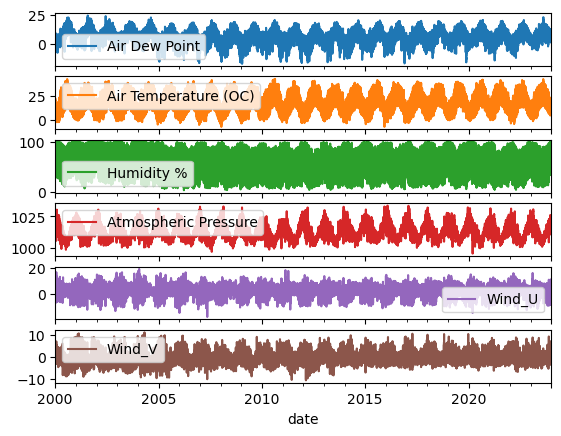

In [6]:
df.set_index('date')[['Air Dew Point', 'Air Temperature (OC)', 'Humidity %','Atmospheric Pressure', 'Wind_U', 'Wind_V']].plot(subplots=True)

In [7]:
df_input=df[['Air Dew Point', 'Air Temperature (OC)', 'Humidity %','Atmospheric Pressure', 'Wind_U', 'Wind_V']]

In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator # Corrected import path

data = df_input.values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

win_length = 24
batch_size = 128
num_features = data_scaled.shape[1]

train_data, test_data = train_test_split(data_scaled, test_size=0.2, shuffle=False)

train_generator = TimeseriesGenerator(
    data=train_data,
    targets=train_data,
    length=win_length,
    sampling_rate=1,
    batch_size=batch_size
)

test_generator = TimeseriesGenerator(
    data=test_data,
    targets=test_data,
    length=win_length,
    sampling_rate=1,
    batch_size=batch_size
)

In [9]:
train_generator[0]

(array([[[0.34845326, 0.33466135, 0.44185294, 0.53950789, 0.46971115,
          0.48717822],
         [0.34845326, 0.3187251 , 0.44185294, 0.53950789, 0.46971115,
          0.48717822],
         [0.34274107, 0.3187251 , 0.47163313, 0.54542622, 0.46971115,
          0.48717822],
         ...,
         [0.33594469, 0.31474104, 0.40392158, 0.56584737, 0.46971115,
          0.48717822],
         [0.32017132, 0.3187251 , 0.40531454, 0.55637592, 0.46971115,
          0.48717822],
         [0.29624082, 0.29880478, 0.4024368 , 0.55075324, 0.46971115,
          0.48717822]],
 
        [[0.34845326, 0.3187251 , 0.44185294, 0.53950789, 0.46971115,
          0.48717822],
         [0.34274107, 0.3187251 , 0.47163313, 0.54542622, 0.46971115,
          0.48717822],
         [0.33975037, 0.24302789, 0.51853266, 0.5543037 , 0.46971115,
          0.48717822],
         ...,
         [0.32017132, 0.3187251 , 0.40531454, 0.55637592, 0.46971115,
          0.48717822],
         [0.29624082, 0.29880478, 0.402

In [10]:
from tensorflow.keras.models import Sequential # Import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

model = Sequential([
    LSTM(units=100, activation='relu', return_sequences=True, input_shape=(48, 6)),
    Dropout(0.2),

    LSTM(units=50, activation='relu', return_sequences=False),
    Dropout(0.2),

    Dense(6)
])
model.compile(optimizer='adam', loss='mse')
model.name = 'VanillaLSTM'
model.summary()

C:\Users\abood\miniconda3\envs\ml-env\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "VanillaLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 48, 100)             │          42,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 48, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 6)                   │             306 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 73,306 (286.35 KB)

 Trainable params: 73,306 (286.35 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense

model = Sequential([
    GRU(units=100, activation='relu', return_sequences=True, input_shape=(48, 6)),
    Dropout(0.2),

    GRU(units=50, activation='relu', return_sequences=False),
    Dropout(0.2),

    Dense(6)
])

model.compile(optimizer='adam', loss='mse')
model.name = 'VanillaGRU'
model.summary()

Model: "VanillaGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 48, 100)             │          32,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 48, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 50)                  │          22,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             306 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,506 (216.82 KB)

 Trainable params: 55,506 (216.82 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
import tensorflow as tf

In [13]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=2,
                                                    mode='min')

model.compile(loss=tf.losses.MeanSquaredError(),
              optimizer=tf.optimizers.Adam(),
              metrics=[tf.metrics.MeanAbsoluteError()])

history = model.fit(train_generator, epochs=100,
                    validation_data=test_generator,
                    shuffle=False,
                    callbacks=[early_stopping])

Epoch 1/100


C:\Users\abood\miniconda3\envs\ml-env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1315/1315 ━━━━━━━━━━━━━━━━━━━━ 110s 79ms/step - loss: 0.0347 - mean_absolute_error: 0.1332 - val_loss: 0.0092 - val_mean_absolute_error: 0.0718
Epoch 2/100
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 104s 79ms/step - loss: 0.0058 - mean_absolute_error: 0.0587 - val_loss: 0.0088 - val_mean_absolute_error: 0.0712
Epoch 3/100
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 105s 80ms/step - loss: 0.0042 - mean_absolute_error: 0.0500 - val_loss: 0.0059 - val_mean_absolute_error: 0.0596
Epoch 4/100
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 105s 80ms/step - loss: 0.0031 - mean_absolute_error: 0.0424 - val_loss: 0.0050 - val_mean_absolute_error: 0.0556
Epoch 5/100
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 104s 79ms/step - loss: 0.0026 - mean_absolute_error: 0.0391 - val_loss: 0.0043 - val_mean_absolute_error: 0.0512
Epoch 6/100
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 101s 77ms/step - loss: 0.0024 - mean_absolute_error: 0.0368 - val_loss: 0.0035 - val_mean_absolute_error: 0.0459
Epoch 7/100
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 105s 80ms/step - loss: 0.0022 - m

In [14]:
import matplotlib.pyplot as plt

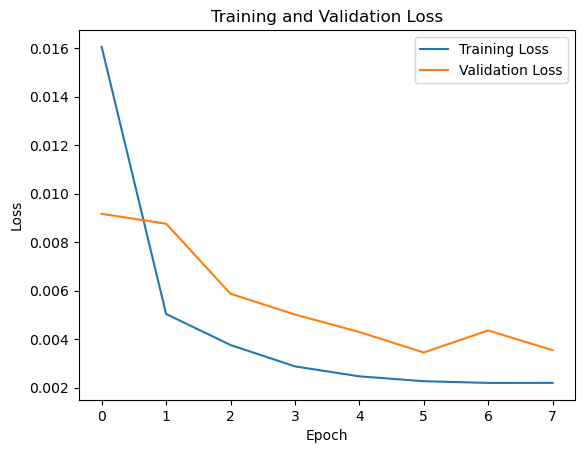

In [15]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [16]:
model.evaluate(test_generator, verbose=0)

[0.0035482735838741064, 0.04638218879699707]

In [17]:
predictions=model.predict(test_generator)

329/329 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step


In [18]:
df_pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(test_data[:,1:][win_length:])],axis=1)

In [19]:
rev_trans=scaler.inverse_transform(df_pred.iloc[:, :6])

In [20]:
df_final=df_input[predictions.shape[0]*-1:]

In [21]:
for i, col in enumerate(df_final.columns):
  df_final.loc[:, 'predicted ' + col] = rev_trans[:, i]


C:\Users\abood\AppData\Local\Temp\ipykernel_20012\1224790544.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.loc[:, 'predicted ' + col] = rev_trans[:, i]
C:\Users\abood\AppData\Local\Temp\ipykernel_20012\1224790544.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.loc[:, 'predicted ' + col] = rev_trans[:, i]
C:\Users\abood\AppData\Local\Temp\ipykernel_20012\1224790544.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

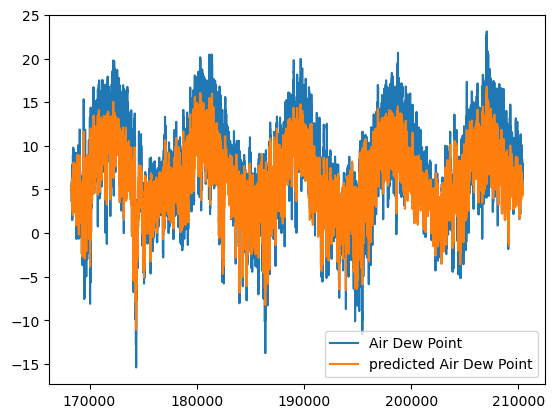

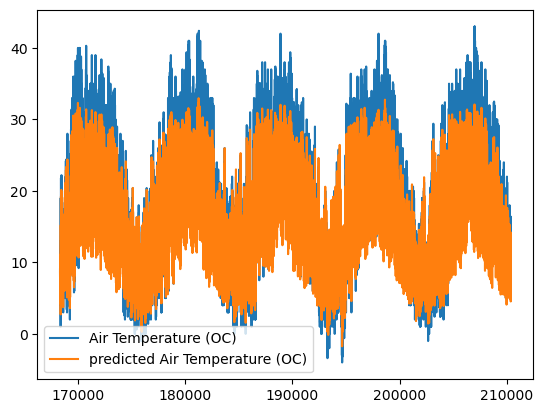

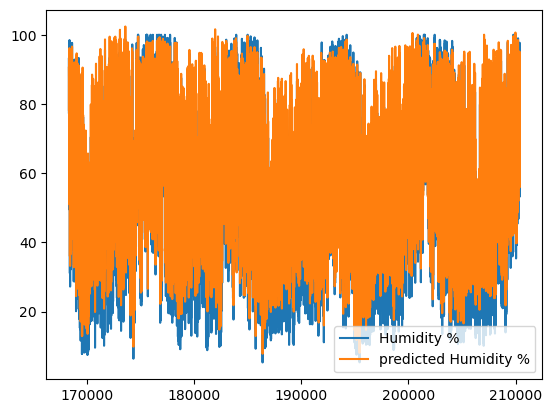

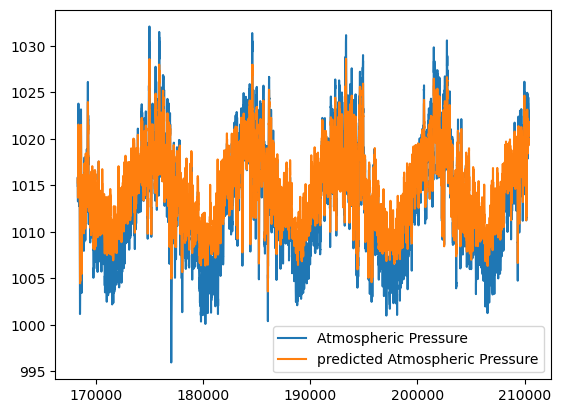

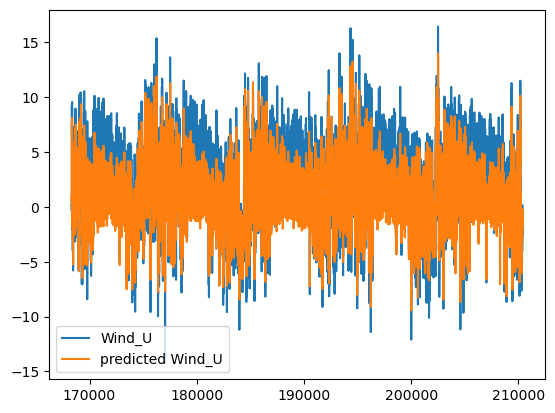

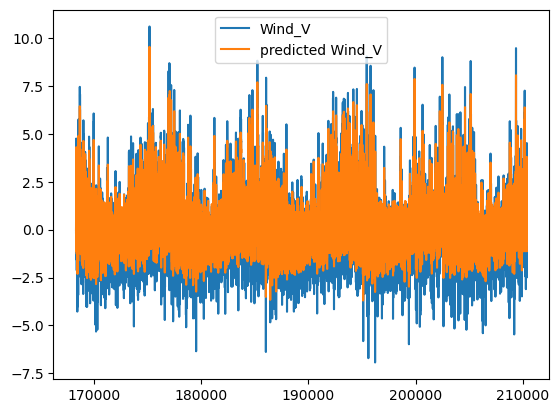

In [22]:
for col in ['Air Dew Point', 'Air Temperature (OC)', 'Humidity %', 'Atmospheric Pressure', 'Wind_U', 'Wind_V']:
  df_final[[col,'predicted '+col]].plot()

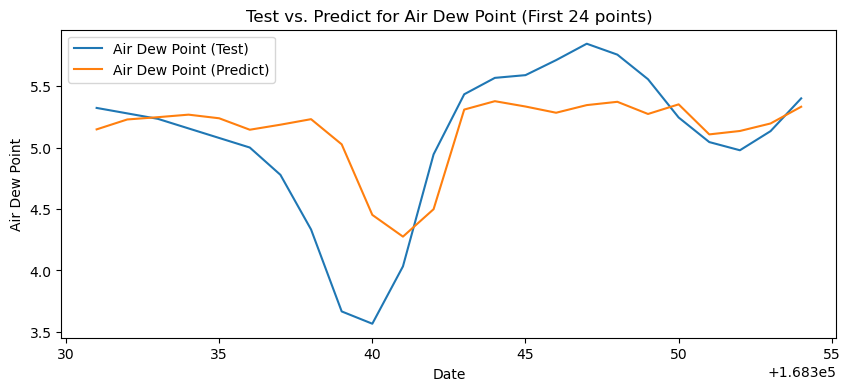

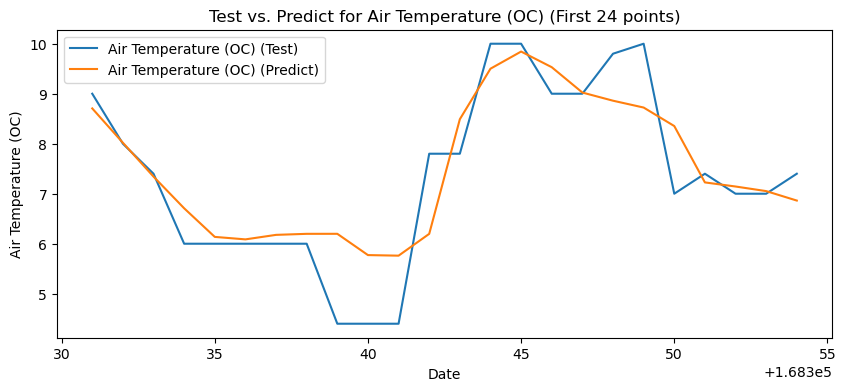

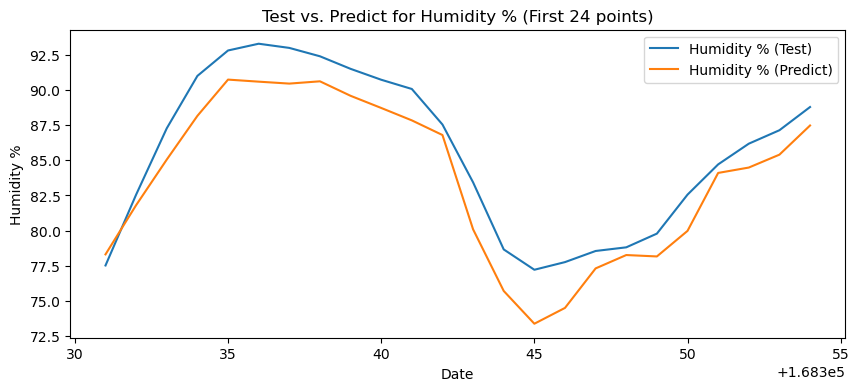

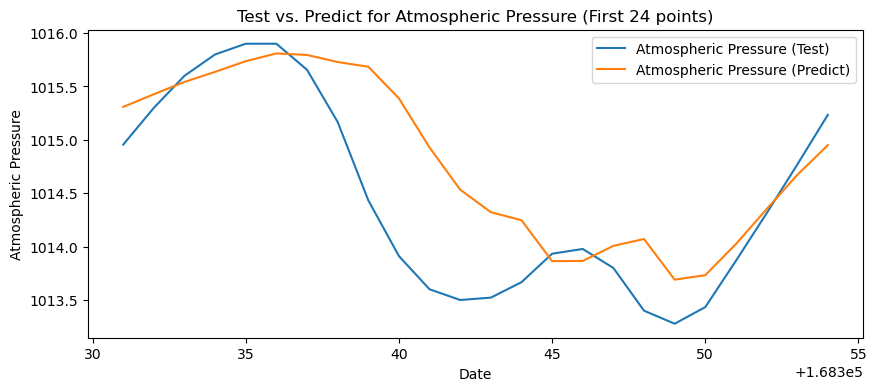

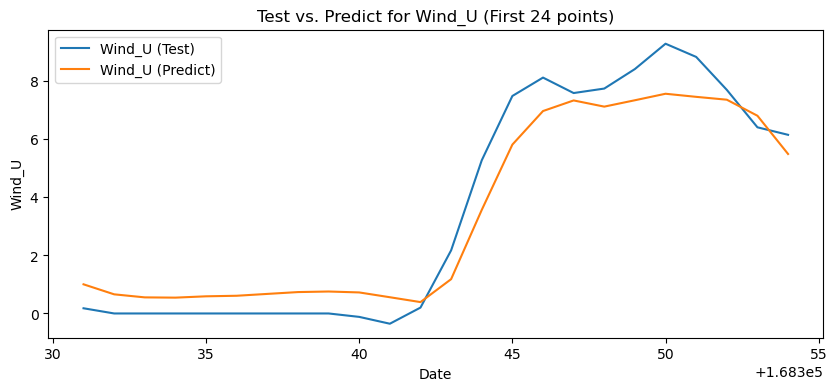

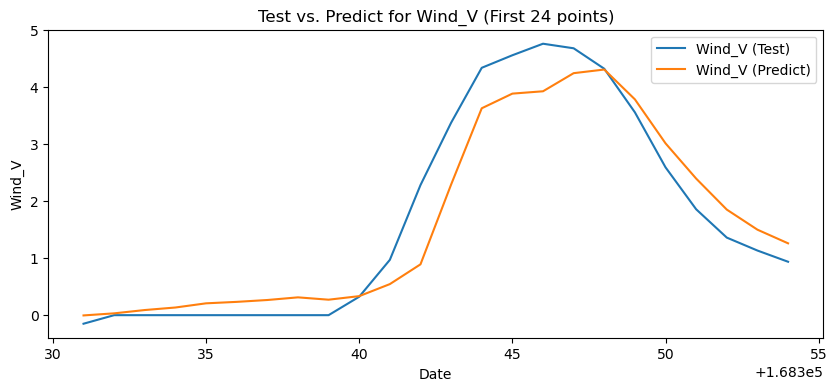

In [23]:
# prompt: plot fisrt 24 points of testvs predict for each feature

# Plotting the first 24 points for each feature
for i, col in enumerate(df_final.columns[:6]): # Iterate through original columns
  plt.figure(figsize=(10, 4))
  plt.plot(df_final.index[:24], df_final[col][:24], label=col + ' (Test)')
  plt.plot(df_final.index[:24], df_final['predicted ' + col][:24], label=col + ' (Predict)')
  plt.title(f'Test vs. Predict for {col} (First 24 points)')
  plt.xlabel('Date')
  plt.ylabel(col)
  plt.legend()
  plt.show()
